# Demand curve plot for the EMS



In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This makes the notebook work both from the repo root and from its own folder.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


## 1. Load and inspect the raw demand profile


In [3]:
demand_file = PROJECT_ROOT / "EMS Control App/python/data/variable_load_signal/scaled_may_power_profile_15min.csv"

demand_raw = pd.read_csv(demand_file)

print("File:", demand_file)
print("Rows:", len(demand_raw))
display(demand_raw.head())
display(demand_raw.describe())


File: C:\Users\Jacob\My Drive\DTU\Bachelor Projekt\Code\Bachelor_repo\Bachelor\EMS Control App\python\data\variable_load_signal\scaled_may_power_profile_15min.csv
Rows: 96


,time_slot,time_of_day,power_mW
0,1,00:00,34.314081
1,2,00:15,33.782637
2,3,00:30,33.251193
3,4,00:45,32.719750
4,5,01:00,32.188306


,time_slot,power_mW
count,96.000000,96.000000
mean,48.500000,41.833295
std,27.856777,15.202156
min,1.000000,15.000000
25%,24.750000,32.485548
50%,48.500000,42.522679
75%,72.250000,49.506691
max,96.000000,75.000000


## 2. Plot the demand profile


<Figure size 1000x400 with 0 Axes>

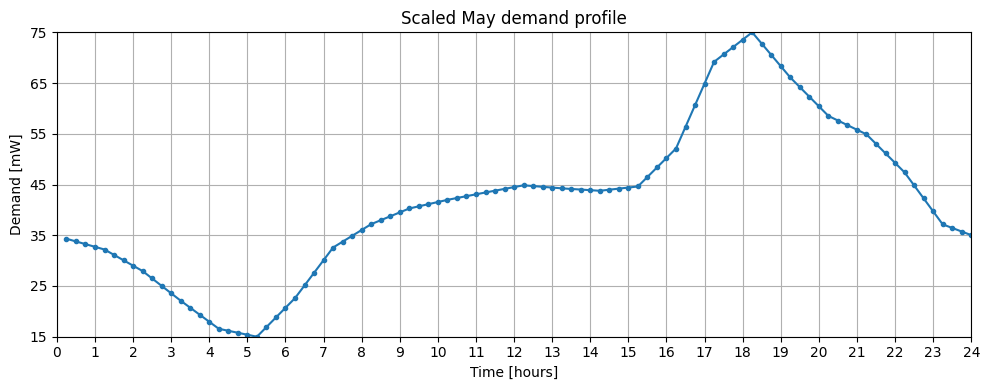

In [5]:
plt.figure(figsize=(10, 4))

plt.plot(
    demand_raw["time_slot"],
    demand_raw["power_mW"],
    marker="o",
    markersize=3
)

plt.title("Scaled May demand profile")
plt.xlabel("Time [hours]")
plt.ylabel("Demand [mW]")

# X-axis: convert 15-minute slots to hours
x_hours = demand_raw["time_slot"] / 4

plt.clf()
plt.figure(figsize=(10, 4))

plt.plot(
    x_hours,
    demand_raw["power_mW"],
    marker="o",
    markersize=3
)

# Show x-axis from 0 to 24 hours
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 1))   # tick every hour

# Y-axis: 15 to 75 with 10 mW increments
plt.ylim(15, 75)
plt.yticks(np.arange(15, 76, 10))

plt.title("Scaled May demand profile")
plt.xlabel("Time [hours]")
plt.ylabel("Demand [mW]")
plt.grid(True)
plt.tight_layout()
plt.show()